# EDA: Scheepspassages Grote Rivieren

Source: `backend/data/26 04 3215 Passages Grote Rivieren.csv` (aangeleverd door WVL via Pam)

**Doel van deze notebook:**
- Begrijpen wat er in de data zit (tijdperiode, rivieren, granulariteit)
- Beoordelen of de ruimtelijke resolutie (blokken) bruikbaar is voor onze ~12k locaties
- Beoordelen of het ontbreken van scheepstype een probleem is
- Concreet advies formuleren voor Pam over wat we eventueel extra nodig hebben van Lars Bettonvil

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DATA_PATH = "../../data/26 04 3215 Passages Grote Rivieren.csv"

## 1. Inladen & eerste blik

In [3]:
df = pd.read_csv(DATA_PATH)

# Strip BOM if present
df.columns = df.columns.str.lstrip('\ufeff').str.strip()

print(df.shape)
df.head(10)

(2922, 5)


,IOL_TRAJECT_CD,IO_NAAM,Maand,Jaar,SUM_of_v14_Aantal_Schepen
0,G11W3,Blok Waal 3 (Druten - Tiel),1,2015,8184
1,G11W3,Blok Waal 3 (Druten - Tiel),2,2015,8360
2,G11W3,Blok Waal 3 (Druten - Tiel),3,2015,9079
3,G11W3,Blok Waal 3 (Druten - Tiel),4,2015,7775
4,G11W3,Blok Waal 3 (Druten - Tiel),5,2015,8493
5,G11W3,Blok Waal 3 (Druten - Tiel),6,2015,8429
6,G11W3,Blok Waal 3 (Druten - Tiel),7,2015,9151
7,G11W3,Blok Waal 3 (Druten - Tiel),8,2015,9701
8,G11W3,Blok Waal 3 (Druten - Tiel),9,2015,9810
9,G11W3,Blok Waal 3 (Druten - Tiel),10,2015,11487


In [4]:
df.dtypes

IOL_TRAJECT_CD               object
IO_NAAM                      object
Maand                         int64
Jaar                          int64
SUM_of_v14_Aantal_Schepen     int64
dtype: object

In [5]:
df.describe()

,Maand,Jaar,SUM_of_v14_Aantal_Schepen
count,2922.000000,2922.000000,2922.000000
mean,6.388433,2020.106092,3143.803559
std,3.468256,3.364999,3162.329337
min,1.000000,2014.000000,1.000000
25%,3.000000,2017.000000,803.250000
50%,6.000000,2020.000000,1520.500000
75%,9.000000,2023.000000,4753.500000
max,12.000000,2026.000000,12864.000000


In [6]:
# Missing values?
df.isnull().sum()

IOL_TRAJECT_CD               0
IO_NAAM                      0
Maand                        0
Jaar                         0
SUM_of_v14_Aantal_Schepen    0
dtype: int64

## 2. Structuur: welke blokken, welke rivieren?

In [7]:
print(f"Unieke blokken: {df['IOL_TRAJECT_CD'].nunique()}")
print(f"Jaar range: {df['Jaar'].min()} – {df['Jaar'].max()}")
print(f"Maand range: {df['Maand'].min()} – {df['Maand'].max()}")
print()

block_info = df.groupby(['IOL_TRAJECT_CD', 'IO_NAAM']).agg(
    n_months=('Maand', 'count'),
    jaar_min=('Jaar', 'min'),
    jaar_max=('Jaar', 'max'),
    total_passages=('SUM_of_v14_Aantal_Schepen', 'sum'),
).reset_index()

block_info

Unieke blokken: 21
Jaar range: 2014 – 2026
Maand range: 1 – 12



,IOL_TRAJECT_CD,IO_NAAM,n_months,jaar_min,jaar_max,total_passages
0,G11W3,Blok Waal 3 (Druten - Tiel),138,2015,2026,1289749
1,G11W4,Blok Waal 4 (Tiel - St. Andries),138,2015,2026,1074011
2,G11W5,Blok Waal 5 (St. Andries - Boven Merwede),138,2015,2026,1023236
3,G12W1,Blok Waal 1 Duitsland - Maas-Waalkanaal,138,2015,2026,1187233
4,G12W2,Blok Waal 2 Maas-Waalkanaal - Druten,138,2015,2026,1221263
5,L51BO,Sluis Born,131,2015,2026,213555
6,L52MB,Sluis Maasbracht,137,2015,2026,249908
7,L57BE,Sluis Belfeld,137,2015,2026,260637
8,L58SA,Sluis Sambeek,137,2015,2026,341268
9,L59GR,Sluis Grave,137,2015,2026,190195


In [14]:
# Categoriseer blokken per rivier op basis van prefix
def classify_river(code):
    if code.startswith('G11W') or code.startswith('G12W'):
        return 'Waal'
    elif code.startswith('L') or code.startswith('M3'):
        return 'Maas / Rijntakken (sluizen)'
    elif code.startswith('N'):
        return 'IJssel'
    else:
        return 'Onbekend'

df['rivier'] = df['IOL_TRAJECT_CD'].apply(classify_river)
block_info['rivier'] = block_info['IOL_TRAJECT_CD'].apply(classify_river)

block_info.sort_values('rivier')

,IOL_TRAJECT_CD,IO_NAAM,n_months,jaar_min,jaar_max,total_passages,rivier
20,N49BZ,Blok Zutphen,137,2015,2026,158214,IJssel
18,N49BD,Blok Doesburg,137,2015,2026,160003,IJssel
17,N48BZ,Blok Zalk,138,2015,2026,95767,IJssel
16,N48BK,Blok Kampen,137,2015,2026,105608,IJssel
15,N48BH,Blok Harkulo,137,2015,2026,87793,IJssel
19,N49BO,Blok Olst,137,2015,2026,175677,IJssel
14,M35SH,Sluis Hagestein,147,2014,2026,148007,Maas / Rijntakken (sluizen)
13,M34SA,Sluis Amerongen,148,2014,2026,170001,Maas / Rijntakken (sluizen)
12,M33SD,Sluis Driel,148,2014,2026,123024,Maas / Rijntakken (sluizen)
11,M31SN,Prinses Beatrixsluis,150,2014,2026,641775,Maas / Rijntakken (sluizen)


## 3. Tijdreeks: hoeveel maanden dekking per blok?

In [15]:
# Verwacht: voor elk blok elke maand van elk jaar een rij
pivot = df.pivot_table(
    index=['Jaar', 'Maand'],
    columns='IOL_TRAJECT_CD',
    values='SUM_of_v14_Aantal_Schepen',
    aggfunc='sum'
)

print("Missende maand×blok combinaties:")
print(pivot.isnull().sum())

Missende maand×blok combinaties:
IOL_TRAJECT_CD
G11W3    12
G11W4    12
G11W5    12
G12W1    12
G12W2    12
L51BO    18
L52MB    12
L57BE    12
L58SA    12
L59GR    12
L60LT    12
M31SN     0
M33SD     2
M34SA     1
M35SH     2
N48BH    12
N48BK    12
N48BZ    12
N49BD    12
N49BO    12
N49BZ    12
dtype: int64


## 4. Jaarlijkse totalen per blok

In [16]:
annual = df.groupby(['IOL_TRAJECT_CD', 'IO_NAAM', 'rivier', 'Jaar'])['SUM_of_v14_Aantal_Schepen'].sum().reset_index()
annual.rename(columns={'SUM_of_v14_Aantal_Schepen': 'passages_per_jaar'}, inplace=True)

annual.head()

,IOL_TRAJECT_CD,IO_NAAM,rivier,Jaar,passages_per_jaar
0,G11W3,Blok Waal 3 (Druten - Tiel),Waal,2015,109973
1,G11W3,Blok Waal 3 (Druten - Tiel),Waal,2016,109583
2,G11W3,Blok Waal 3 (Druten - Tiel),Waal,2017,109412
3,G11W3,Blok Waal 3 (Druten - Tiel),Waal,2018,120097
4,G11W3,Blok Waal 3 (Druten - Tiel),Waal,2019,117646


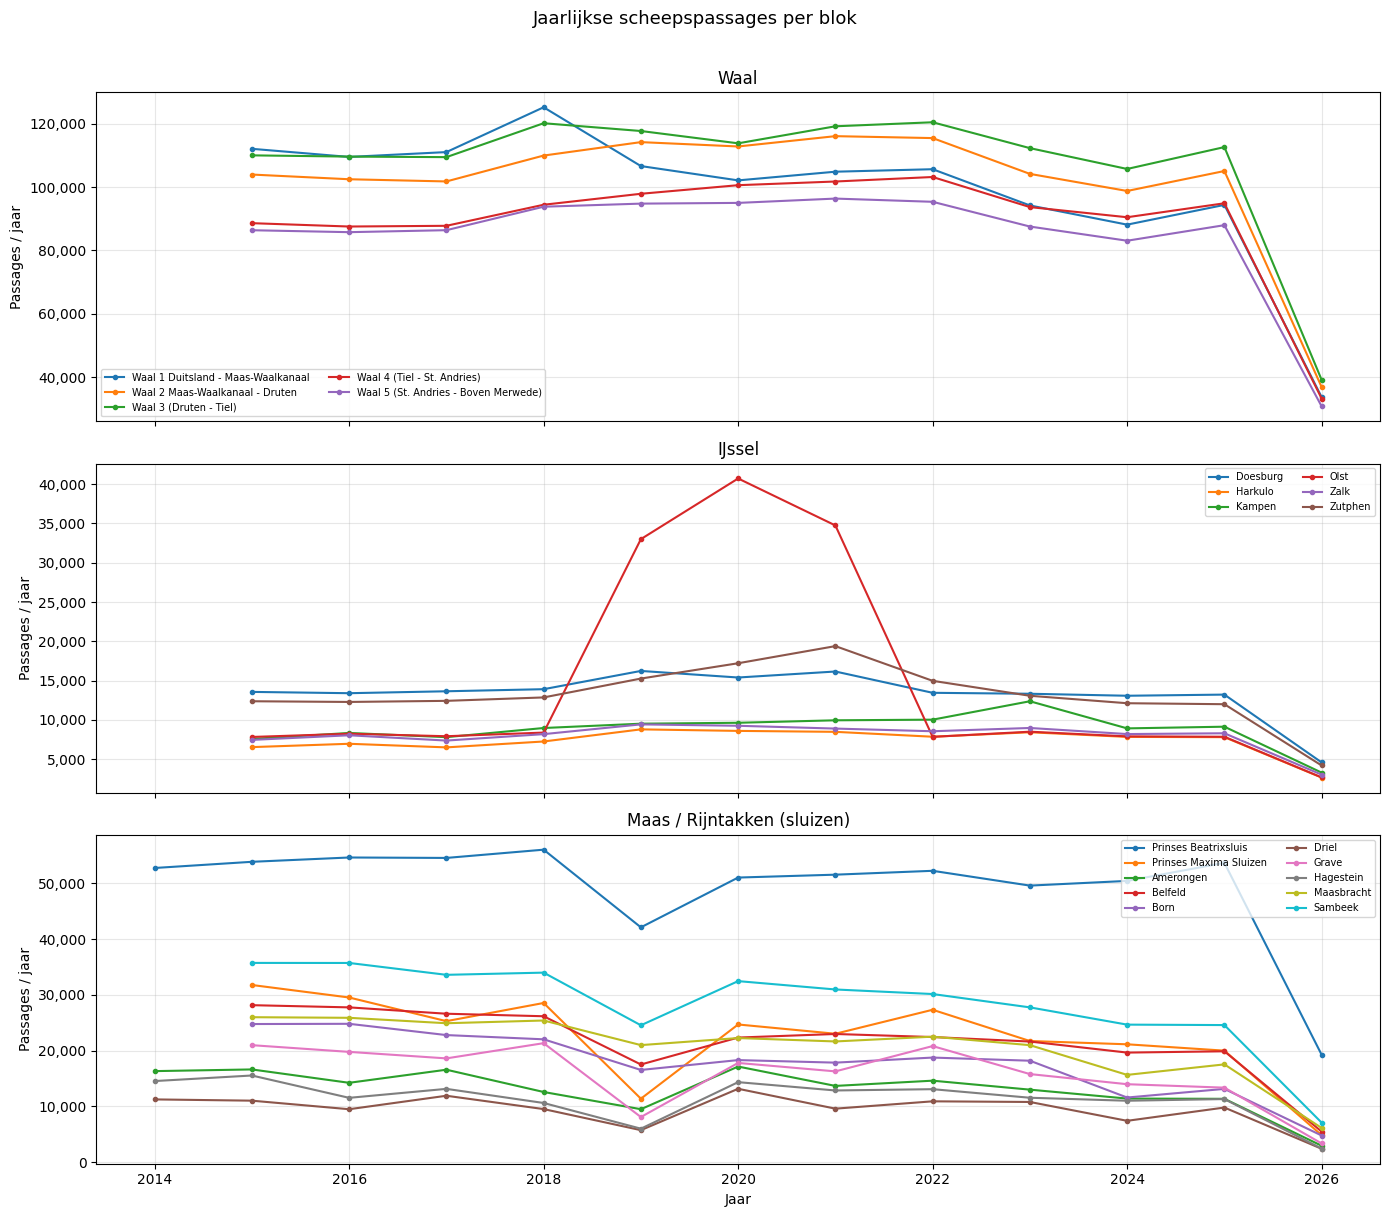

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

rivers = ['Waal', 'IJssel', 'Maas / Rijntakken (sluizen)']

for ax, rivier in zip(axes, rivers):
    subset = annual[annual['rivier'] == rivier]
    for name, grp in subset.groupby('IO_NAAM'):
        label = name.replace('Blok ', '').replace('Sluis ', '')
        ax.plot(grp['Jaar'], grp['passages_per_jaar'], marker='o', markersize=3, label=label)
    ax.set_title(rivier)
    ax.set_ylabel('Passages / jaar')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Jaar')
plt.suptitle('Jaarlijkse scheepspassages per blok', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Seizoenspatroon

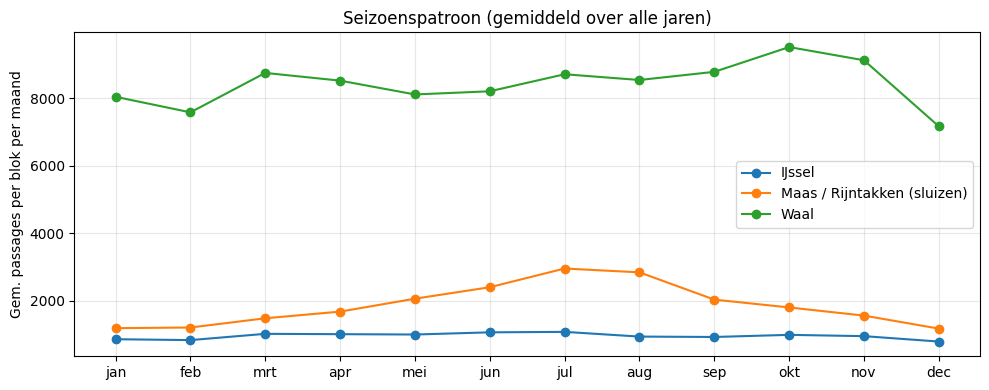

In [12]:
monthly_avg = df.groupby(['rivier', 'Maand'])['SUM_of_v14_Aantal_Schepen'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for rivier, grp in monthly_avg.groupby('rivier'):
    ax.plot(grp['Maand'], grp['SUM_of_v14_Aantal_Schepen'], marker='o', label=rivier)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['jan','feb','mrt','apr','mei','jun','jul','aug','sep','okt','nov','dec'])
ax.set_ylabel('Gem. passages per blok per maand')
ax.set_title('Seizoenspatroon (gemiddeld over alle jaren)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Ruimtelijke resolutie: match met onze erosielocaties?

Onze erosielocaties (`punten_oever`) hebben een `location_id` per meetpunt.
De scheepsdata zit op **rivierblok**-niveau — elk blok dekt tientallen kilometers.

Hieronder overzicht van de blokken en hun (geschatte) bereik, zodat we kunnen beoordelen hoeveel erosielocaties per blok vallen.

In [13]:
# Overzicht blokken met naam (voor handmatige km-check)
block_info[['IOL_TRAJECT_CD', 'IO_NAAM', 'rivier', 'jaar_min', 'jaar_max', 'total_passages']].sort_values(['rivier', 'IOL_TRAJECT_CD'])

,IOL_TRAJECT_CD,IO_NAAM,rivier,jaar_min,jaar_max,total_passages
15,N48BH,Blok Harkulo,IJssel,2015,2026,87793
16,N48BK,Blok Kampen,IJssel,2015,2026,105608
17,N48BZ,Blok Zalk,IJssel,2015,2026,95767
18,N49BD,Blok Doesburg,IJssel,2015,2026,160003
19,N49BO,Blok Olst,IJssel,2015,2026,175677
20,N49BZ,Blok Zutphen,IJssel,2015,2026,158214
5,L51BO,Sluis Born,Maas / Rijntakken (sluizen),2015,2026,213555
6,L52MB,Sluis Maasbracht,Maas / Rijntakken (sluizen),2015,2026,249908
7,L57BE,Sluis Belfeld,Maas / Rijntakken (sluizen),2015,2026,260637
8,L58SA,Sluis Sambeek,Maas / Rijntakken (sluizen),2015,2026,341268


### TODO: koppeling met GeoPackage
Als we de GeoPackage (`punten_oever`) inladen, kunnen we:
1. Elke `location_id` ruimtelijk aan een blok koppelen (punt-in-polygoon of dichtstbijzijnde centroïde)
2. Tellen hoeveel locaties per blok vallen → geeft een idee van de resolutie-impact

## 7. Conclusies & vraag aan Lars

### Wat we hebben
- Maandelijkse **aantallen** scheepspassages per blok, 2015–heden
- Dekking: **Waal** (5 blokken), **IJssel** (6 blokken), **Maas** (sluizen/blokken)
- Geen scheepstype, geen afmetingen, geen vaarweg-km

### Pams zorgen — terecht?

| Zorg | Beoordeling |
|------|-------------|
| Blokken te grof voor locatie-koppeling | **Ja, waarschijnlijk wel een probleem.** Een blok dekt tientallen km; binnen één blok kunnen erosiepatronen sterk variëren. Voor een eerste feature (jaarlijks gemiddeld per blok) is het bruikbaar, maar fijner is beter. |
| Geen scheepstype | **Ja, relevant.** Een duwvaartkonvooi heeft een andere golfslag dan een klein motorschip. Klasse IV/Va/Vb + duwbakken zijn het meest erosief. |

### Wat te vragen aan Lars Bettonvil?

Prioriteit:
1. **Uitsplitsing naar CEMT-klasse of scheepstype** (duwvaart, motorvrachtschip, tankschip, recreatie) — dit is de hoogste meerwaarde
2. **Fijnere ruimtelijke indeling**: hectometer-niveau of in ieder geval sub-blok (bijv. per 5 km) langs de Waal/IJssel/Maas
3. **Laadvermogen of waterverplaatsing** (breedte × diepgang) als proxy voor golfimpact — alternatief voor type

Minimumwens voor feature-engineering: uitsplitsing per **scheepsklasse** (CEMT groot / klein) bij de huidige blokgranulariteit is al een stap vooruit.